# Week 4 — Wednesday: Feature Matching & Image Alignment

## Learning Objectives
- Understand how feature descriptors are matched between images
- Implement Brute-Force and FLANN matchers
- Apply Lowe's ratio test to remove ambiguous matches
- Use RANSAC to robustly estimate homography
- Align two images using the computed homography

## Key Concepts
1. **Brute-Force Matcher** — compare every descriptor pair; exact, O(N²)
2. **FLANN Matcher** — approximate nearest-neighbour; fast at scale
3. **Lowe's Ratio Test** — keep only unambiguous matches (d1 < ratio × d2)
4. **RANSAC** — robustly fit a homography despite outliers
5. **Homography** — 3×3 projective transform mapping one image plane to another
6. **warpPerspective** — apply the homography to warp/align images

## Section 1: Imports & Setup

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time

plt.rcParams['figure.figsize'] = (14, 8)
print('OpenCV version:', cv2.__version__)

OpenCV version: 4.13.0


## Section 2: Creating a Synthetic Test Pair

We build two images of the same scene where the ground-truth transform is
**10° rotation + 20 px right + 30 px down**.
Using a synthetic pair means we know exactly what the correct homography
should recover, making it easy to verify our pipeline.

**Why ORB?** ORB (Oriented FAST + Rotated BRIEF) is:
- Free (no patent restrictions unlike SIFT/SURF)
- Fast — designed for real-time use
- Binary descriptors → use Hamming distance, not Euclidean

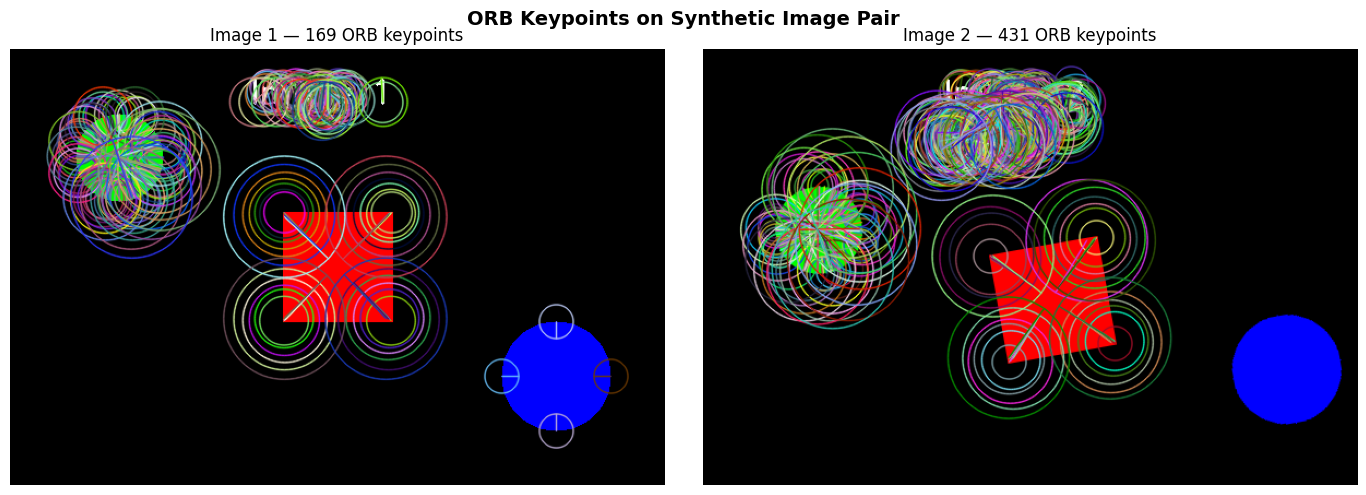

Image 1 keypoints : 169
Image 2 keypoints : 431
Descriptor shape  : (169, 32)  (dtype=uint8)


In [2]:
# ── Build Image 1 ─────────────────────────────────────────────────────────
img1 = np.zeros((400, 600, 3), dtype=np.uint8)
cv2.circle(img1,    (100, 100), 40,  (0, 255, 0),  -1)   # green circle
cv2.rectangle(img1, (250, 150), (350, 250), (0, 0, 255), -1)  # blue rect
cv2.circle(img1,    (500, 300), 50,  (255, 0, 0),  -1)   # red circle
cv2.putText(img1, 'Image 1', (220, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

# ── Build Image 2 (rotated + translated) ──────────────────────────────────
M_rot   = cv2.getRotationMatrix2D((300, 200), 10, 1.0)   # 10 deg
img2    = cv2.warpAffine(img1, M_rot, (600, 400))
M_trans = np.float32([[1, 0, 20], [0, 1, 30]])            # +20px, +30px
img2    = cv2.warpAffine(img2, M_trans, (600, 400))
cv2.putText(img2, 'Image 2', (220, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

# ── Grayscale ──────────────────────────────────────────────────────────────
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ── ORB detection ──────────────────────────────────────────────────────────
orb = cv2.ORB_create(nfeatures=500)
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# ── Visualise ──────────────────────────────────────────────────────────────
img1_kp = cv2.drawKeypoints(img1, kp1, None,
                            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_kp = cv2.drawKeypoints(img2, kp2, None,
                            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(img1_kp, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Image 1 — {len(kp1)} ORB keypoints')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img2_kp, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Image 2 — {len(kp2)} ORB keypoints')
axes[1].axis('off')
plt.suptitle('ORB Keypoints on Synthetic Image Pair', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Image 1 keypoints : {len(kp1)}')
print(f'Image 2 keypoints : {len(kp2)}')
print(f'Descriptor shape  : {des1.shape}  (dtype={des1.dtype})')

## Section 3: Brute-Force Matcher

### How it works
For **every** descriptor in image 1, compute the Hamming distance to
**every** descriptor in image 2 and pick the nearest neighbour.

| Parameter | Meaning |
|-----------|--------|
| `NORM_HAMMING` | Distance metric for binary descriptors (ORB, BRIEF) |
| `crossCheck=True` | Keep only symmetric matches: A→B AND B→A must agree |

**Complexity**: O(N × M) — works well for small descriptor sets (<1000 each).

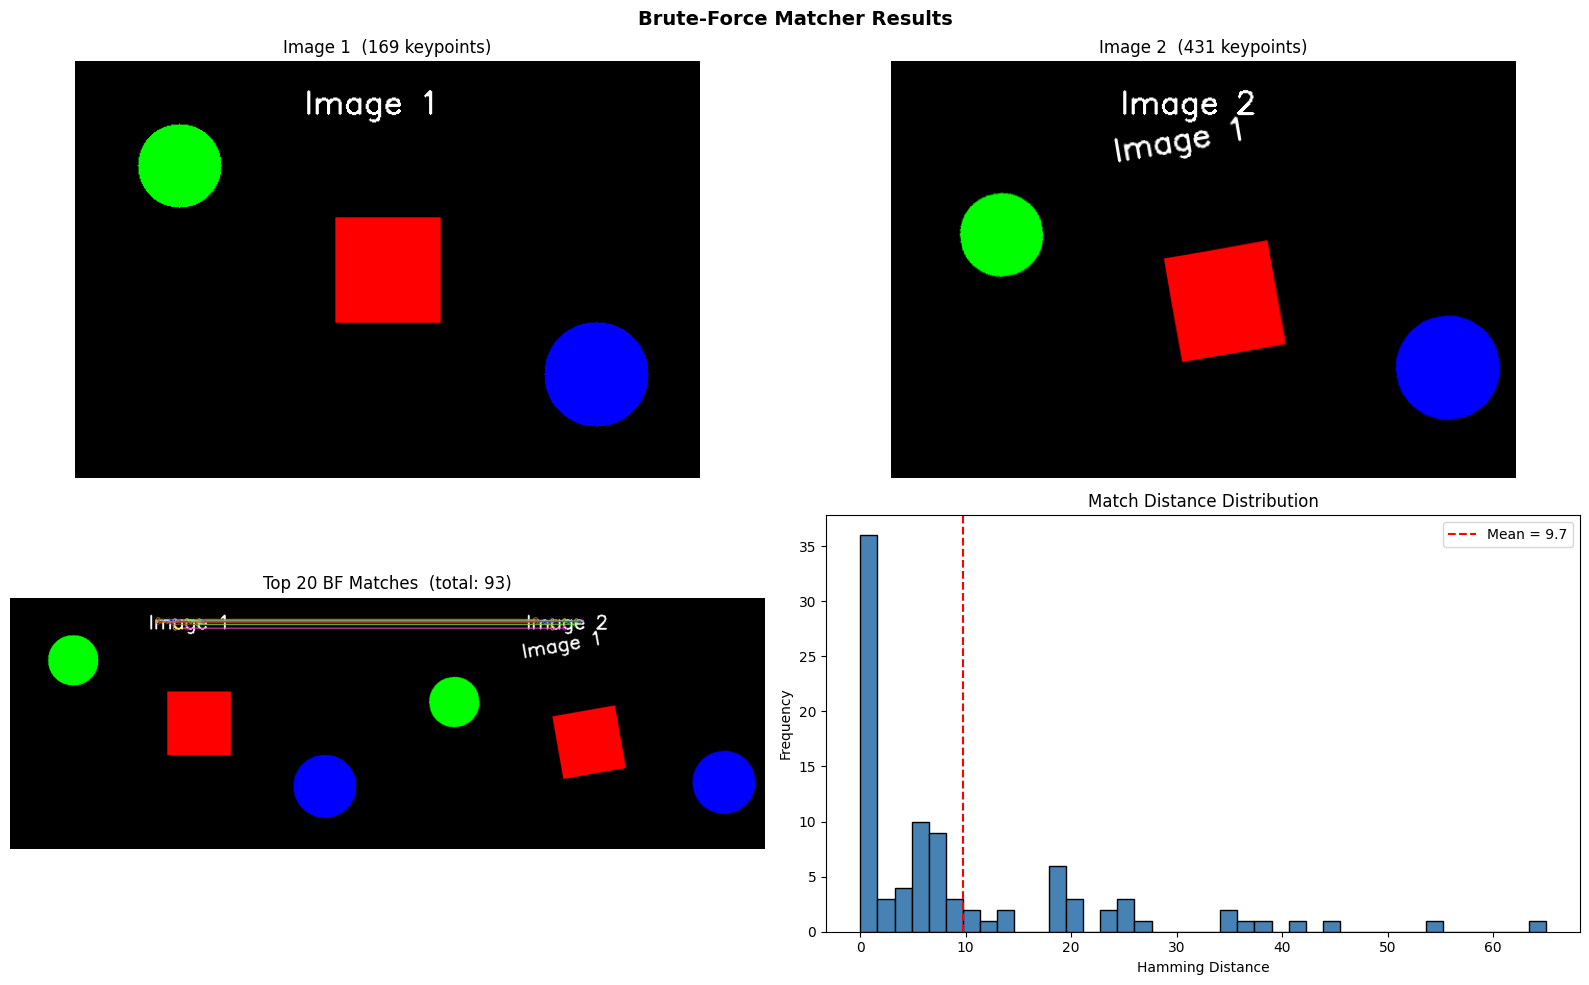

Total BF matches   : 93
Best  distance     : 0
Worst distance     : 65
Mean  distance     : 9.7
Median distance    : 6.0

Top 5 matches (queryIdx → trainIdx : distance):
  [1]   0 ->  69 : dist=0.0
  [2]   1 ->   2 : dist=0.0
  [3]   2 ->   3 : dist=0.0
  [4]   3 ->   4 : dist=0.0
  [5]   4 ->   5 : dist=0.0


In [3]:
# ── Brute-Force with cross-check ──────────────────────────────────────────
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches_bf = bf.match(des1, des2)
matches_bf = sorted(matches_bf, key=lambda x: x.distance)

# Draw top 20 matches
draw_bf = cv2.drawMatches(
    img1, kp1, img2, kp2, matches_bf[:20], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Distance histogram
distances = [m.distance for m in matches_bf]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f'Image 1  ({len(kp1)} keypoints)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Image 2  ({len(kp2)} keypoints)')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(draw_bf, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title(f'Top 20 BF Matches  (total: {len(matches_bf)})')
axes[1, 0].axis('off')

axes[1, 1].hist(distances, bins=40, color='steelblue', edgecolor='black')
axes[1, 1].axvline(np.mean(distances), color='red', linestyle='--',
                   label=f'Mean = {np.mean(distances):.1f}')
axes[1, 1].set_title('Match Distance Distribution')
axes[1, 1].set_xlabel('Hamming Distance')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.suptitle('Brute-Force Matcher Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total BF matches   : {len(matches_bf)}')
print(f'Best  distance     : {matches_bf[0].distance:.0f}')
print(f'Worst distance     : {matches_bf[-1].distance:.0f}')
print(f'Mean  distance     : {np.mean(distances):.1f}')
print(f'Median distance    : {np.median(distances):.1f}')
print('\nTop 5 matches (queryIdx → trainIdx : distance):')
for i, m in enumerate(matches_bf[:5]):
    print(f'  [{i+1}] {m.queryIdx:3d} -> {m.trainIdx:3d} : dist={m.distance}')

## Section 4: Lowe's Ratio Test

### Problem with raw BF matches
Some descriptor matches are **ambiguous** — the best match is only slightly
better than the second-best. These are likely wrong.

### Lowe's solution (SIFT paper, 2004)
Request the **2 nearest neighbours** for each descriptor, then keep the match
only when:

$$d_1 < \text{ratio} \times d_2$$

If the best match distance is much smaller than the second-best, the match is
unambiguous and we keep it. The original paper recommends **ratio = 0.7–0.8**.

| Ratio | Effect |
|-------|-------|
| 0.5 | Very strict — few but very reliable matches |
| 0.7 | Standard — good balance of precision and recall |
| 0.9 | Lenient — many matches, more noise |

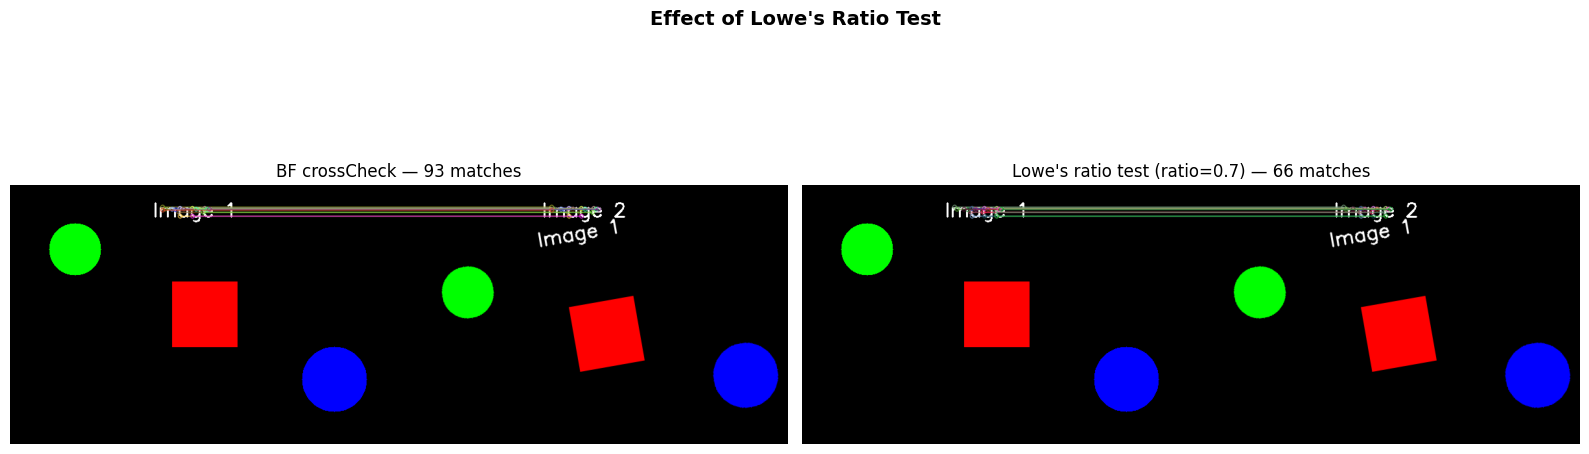

kNN matches (raw)      : 169
After ratio test       : 66
Removed (ambiguous)    : 103
Reduction              : 60.9%

Sensitivity to ratio threshold:
  ratio=0.50  ->   53 matches
  ratio=0.60  ->   59 matches
  ratio=0.70  ->   66 matches
  ratio=0.75  ->   72 matches
  ratio=0.80  ->   84 matches
  ratio=0.90  ->  116 matches


In [4]:
# ── kNN match with k=2 ────────────────────────────────────────────────────
bf_knn = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches_knn = bf_knn.knnMatch(des1, des2, k=2)

# ── Apply ratio test ──────────────────────────────────────────────────────
RATIO = 0.7
good_matches = []
for pair in matches_knn:
    if len(pair) == 2:
        m, n = pair
        if m.distance < RATIO * n.distance:
            good_matches.append(m)

draw_good = cv2.drawMatches(
    img1, kp1, img2, kp2, good_matches[:20], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(draw_bf, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'BF crossCheck — {len(matches_bf)} matches')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(draw_good, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Lowe's ratio test (ratio={RATIO}) — {len(good_matches)} matches")
axes[1].axis('off')
plt.suptitle("Effect of Lowe's Ratio Test", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'kNN matches (raw)      : {len(matches_knn)}')
print(f'After ratio test       : {len(good_matches)}')
print(f'Removed (ambiguous)    : {len(matches_knn) - len(good_matches)}')
print(f'Reduction              : {(1 - len(good_matches)/len(matches_knn))*100:.1f}%')

# ── Ratio threshold sensitivity ────────────────────────────────────────────
print('\nSensitivity to ratio threshold:')
for r in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    gm = [m for pair in matches_knn if len(pair) == 2
          for m, n in [pair] if m.distance < r * n.distance]
    print(f'  ratio={r:.2f}  ->  {len(gm):3d} matches')

## Section 5: RANSAC for Robust Homography Estimation

### Problem
Even after the ratio test, some outliers remain. A simple least-squares
homography fit would be corrupted by them.

### RANSAC (Random Sample Consensus)
1. Randomly pick **4** point correspondences (minimum needed for a homography)
2. Fit a homography H to those 4 points
3. Count **inliers** — matches whose reprojection error is below a threshold
4. Repeat N times, keep the H with the most inliers
5. Re-fit H using all inliers of the best model

`cv2.findHomography(..., cv2.RANSAC, reprojThresh)` runs this internally
and returns the homography matrix **H** and a binary **mask** (1=inlier, 0=outlier).

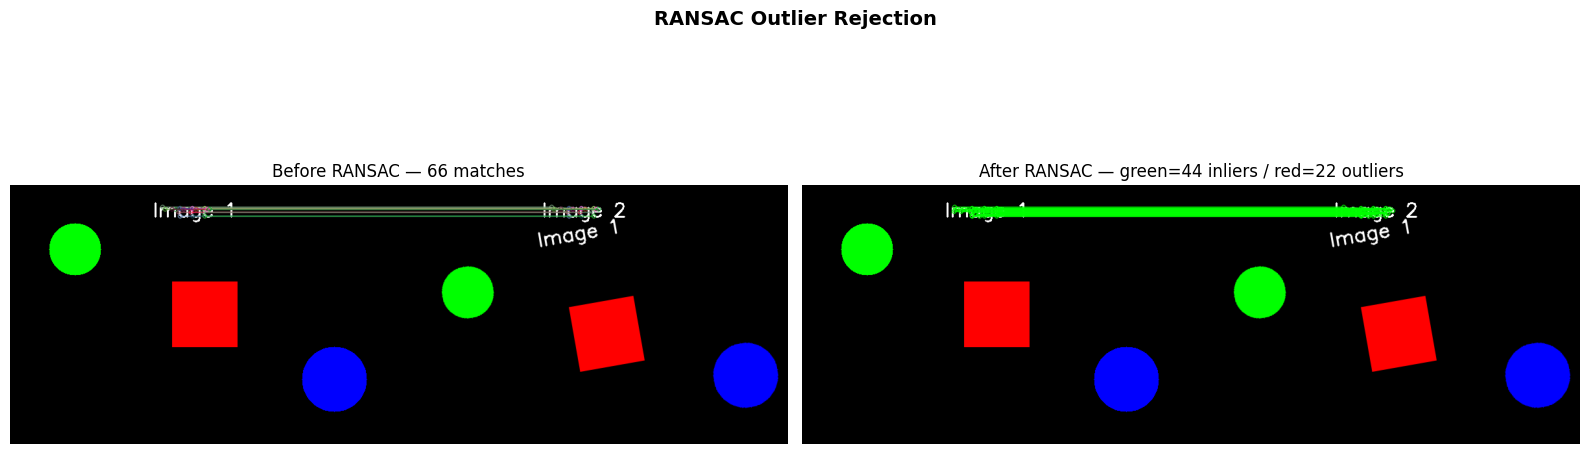

RANSAC Results
  Input matches  : 66
  Inliers        : 44  (66.7%)
  Outliers       : 22

Homography Matrix H:
[[ 1.00000000e+00 -8.89341134e-15  3.70820290e-14]
 [ 1.51510085e-16  1.00000000e+00  2.56940384e-14]
 [ 3.71839357e-18 -2.90679227e-17  1.00000000e+00]]


In [5]:
H = None
mask = None

if len(good_matches) >= 4:
    src_pts = np.float32(
        [kp1[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    dst_pts = np.float32(
        [kp2[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    inliers  = int(np.sum(mask))
    outliers = len(good_matches) - inliers

    # Draw with inlier mask
    draw_ransac = cv2.drawMatches(
        img1, kp1, img2, kp2, good_matches, None,
        matchColor=(0, 255, 0),
        singlePointColor=(0, 0, 255),
        matchesMask=mask.ravel().tolist(),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(cv2.cvtColor(draw_good, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Before RANSAC — {len(good_matches)} matches')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(draw_ransac, cv2.COLOR_BGR2RGB))
    axes[1].set_title(
        f'After RANSAC — green={inliers} inliers / red={outliers} outliers'
    )
    axes[1].axis('off')
    plt.suptitle('RANSAC Outlier Rejection', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('RANSAC Results')
    print(f'  Input matches  : {len(good_matches)}')
    print(f'  Inliers        : {inliers}  ({inliers/len(good_matches)*100:.1f}%)')
    print(f'  Outliers       : {outliers}')
    print(f'\nHomography Matrix H:')
    print(H)
else:
    print('Not enough good matches to compute homography.')

## Section 6: Image Alignment via Homography

With a reliable **H** we can warp image 2 into the coordinate frame of
image 1 using `cv2.warpPerspective`.

**Expected result**: after warping, image 2 should look nearly identical to
image 1 — the blended overlay should show clean shapes with minimal ghosting,
and the mean pixel difference should be close to zero.

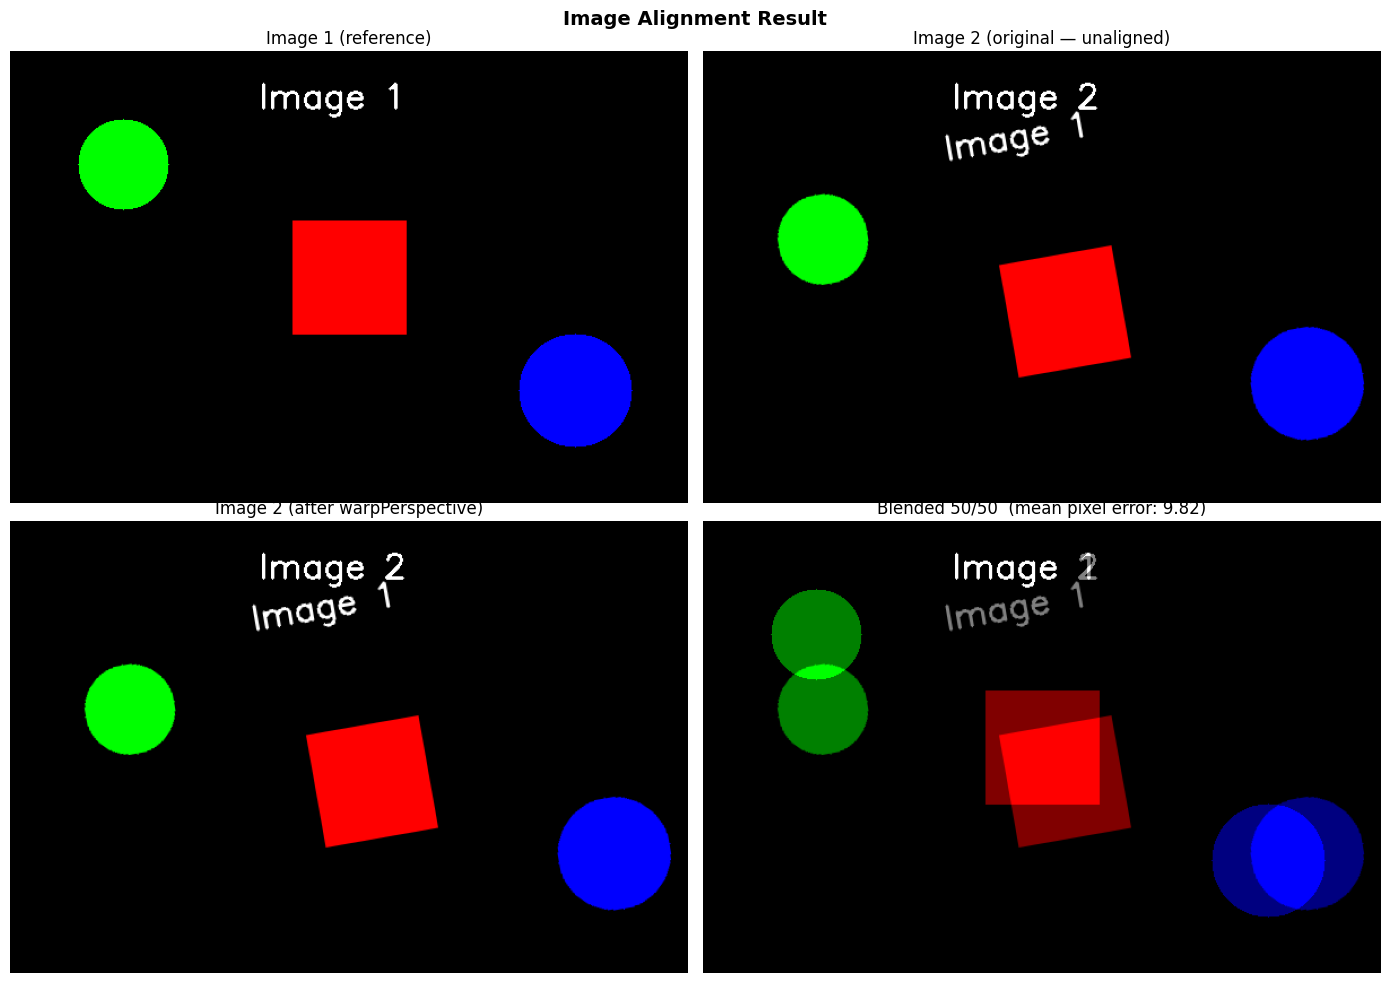

Alignment complete!
Mean pixel error (img1 vs aligned img2): 9.82


In [6]:
if H is not None:
    h, w = img1.shape[:2]
    img2_aligned = cv2.warpPerspective(img2, H, (w, h))

    blended  = cv2.addWeighted(img1, 0.5, img2_aligned, 0.5, 0)
    diff_img = cv2.absdiff(img1, img2_aligned)
    mean_err = np.mean(diff_img)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Image 1 (reference)')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Image 2 (original — unaligned)')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(cv2.cvtColor(img2_aligned, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('Image 2 (after warpPerspective)')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title(f'Blended 50/50  (mean pixel error: {mean_err:.2f})')
    axes[1, 1].axis('off')

    plt.suptitle('Image Alignment Result', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Alignment complete!')
    print(f'Mean pixel error (img1 vs aligned img2): {mean_err:.2f}')
else:
    print('No homography available — run Section 5 first.')

## Section 7: FLANN Matcher

**FLANN** (Fast Library for Approximate Nearest Neighbours) replaces the
exhaustive Brute-Force search with randomised index structures.

| Matcher | Accuracy | Complexity | Best for |
|---------|----------|-----------|----------|
| BF | Exact | O(N²) | Small datasets (<1 K descriptors) |
| FLANN | Approximate | O(N log N) | Large datasets (>10 K descriptors) |

### Index type for binary descriptors (ORB, BRIEF)
Use **LSH** (Locality-Sensitive Hashing) — `FLANN_INDEX_LSH = 6`

```python
index_params = dict(algorithm=6,        # LSH
                    table_number=12,
                    key_size=20,
                    multi_probe_level=2)
```

Timing Comparison
  Brute-Force : 0.458 ms
  FLANN       : 3.551 ms
  Speedup     : 0.1x

Good matches (ratio=0.7)
  BF    : 66
  FLANN : 66


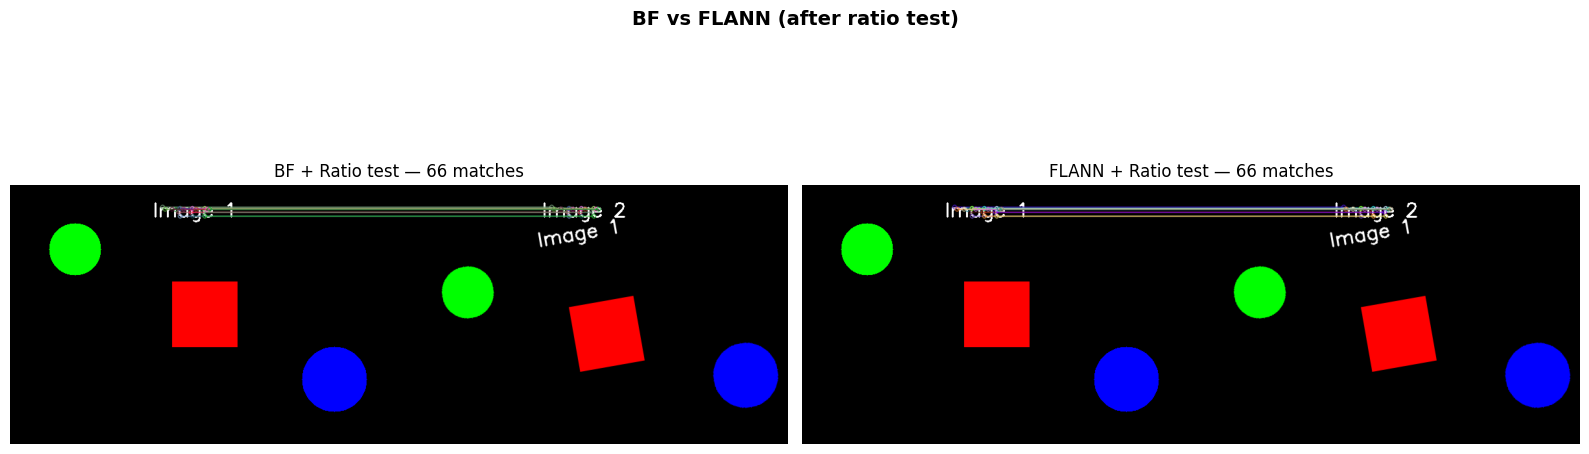

In [7]:
FLANN_INDEX_LSH = 6
index_params  = dict(algorithm=FLANN_INDEX_LSH,
                     table_number=12,
                     key_size=20,
                     multi_probe_level=2)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# ── Time FLANN ────────────────────────────────────────────────────────────
t0 = time.time()
matches_flann = flann.knnMatch(des1, des2, k=2)
flann_ms = (time.time() - t0) * 1000

# ── Time BF for comparison ────────────────────────────────────────────────
bf2 = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
t0 = time.time()
matches_bf2 = bf2.knnMatch(des1, des2, k=2)
bf2_ms = (time.time() - t0) * 1000

speedup = bf2_ms / flann_ms if flann_ms > 0 else float('inf')

print('Timing Comparison')
print(f'  Brute-Force : {bf2_ms:.3f} ms')
print(f'  FLANN       : {flann_ms:.3f} ms')
print(f'  Speedup     : {speedup:.1f}x')

# ── Ratio test on FLANN matches ───────────────────────────────────────────
good_flann = [m for pair in matches_flann if len(pair) == 2
              for m, n in [pair] if m.distance < RATIO * n.distance]

print(f'\nGood matches (ratio={RATIO})')
print(f'  BF    : {len(good_matches)}')
print(f'  FLANN : {len(good_flann)}')

# ── Visualise side-by-side ────────────────────────────────────────────────
draw_flann = cv2.drawMatches(
    img1, kp1, img2, kp2, good_flann[:20], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(draw_good,  cv2.COLOR_BGR2RGB))
axes[0].set_title(f'BF + Ratio test — {len(good_matches)} matches')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(draw_flann, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'FLANN + Ratio test — {len(good_flann)} matches')
axes[1].axis('off')
plt.suptitle('BF vs FLANN (after ratio test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 8: Full End-to-End Pipeline

A clean, reusable function that runs the entire matching pipeline:

```
detect keypoints  →  compute descriptors  →  kNN match
  →  ratio filter  →  RANSAC homography  →  warpPerspective
```

Running pipeline on test pair:
  Keypoints    : 169 / 431
  Raw matches  : 169
  Good matches : 66
  Inliers      : 44
  H computed   : True


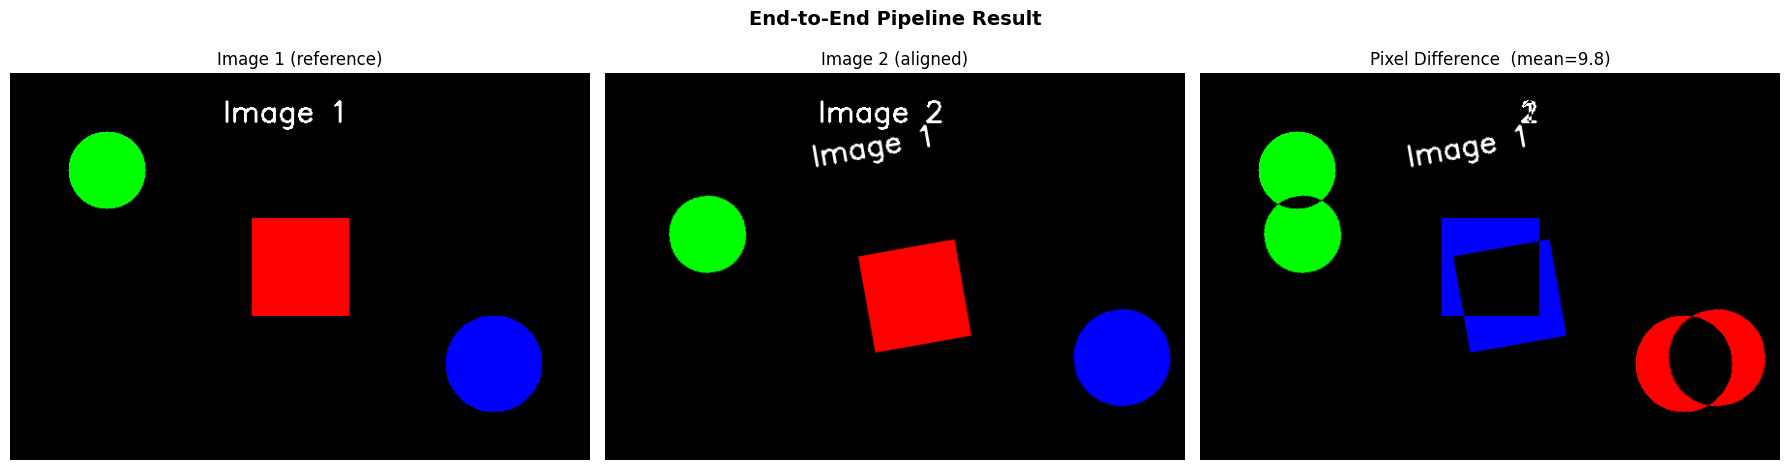

In [8]:
def feature_matching_pipeline(img_a, img_b, ratio=0.7, ransac_thresh=5.0):
    """Detect, match, filter, and align two images.
    Returns: H, good_matches, mask, kp_a, kp_b
    """
    gray_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2GRAY)
    gray_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=500)
    kp_a, des_a = orb.detectAndCompute(gray_a, None)
    kp_b, des_b = orb.detectAndCompute(gray_b, None)

    bf  = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    raw = bf.knnMatch(des_a, des_b, k=2)

    good = [m for pair in raw if len(pair) == 2
            for m, n in [pair] if m.distance < ratio * n.distance]

    H, mask, inliers = None, None, 0
    if len(good) >= 4:
        src = np.float32([kp_a[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_b[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src, dst, cv2.RANSAC, ransac_thresh)
        inliers = int(np.sum(mask)) if mask is not None else 0

    print(f'  Keypoints    : {len(kp_a)} / {len(kp_b)}')
    print(f'  Raw matches  : {len(raw)}')
    print(f'  Good matches : {len(good)}')
    print(f'  Inliers      : {inliers}')
    print(f'  H computed   : {H is not None}')
    return H, good, mask, kp_a, kp_b


print('Running pipeline on test pair:')
H_out, good_out, mask_out, kpa, kpb = feature_matching_pipeline(img1, img2)

if H_out is not None:
    h, w    = img1.shape[:2]
    aligned = cv2.warpPerspective(img2, H_out, (w, h))
    diff    = cv2.absdiff(img1, aligned)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(img1,    cv2.COLOR_BGR2RGB))
    axes[0].set_title('Image 1 (reference)')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Image 2 (aligned)')
    axes[1].axis('off')
    axes[2].imshow(diff)
    axes[2].set_title(f'Pixel Difference  (mean={np.mean(diff):.1f})')
    axes[2].axis('off')
    plt.suptitle('End-to-End Pipeline Result', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Section 9: Key Takeaways

| Concept | One-line summary |
|---------|------------------|
| **BF Matcher** | Exact O(N²) — great for small datasets |
| **FLANN** | Approximate O(N log N) — use for large datasets |
| **Lowe's Ratio Test** | Discard ambiguous matches: `d1 < 0.7 × d2` |
| **RANSAC** | Robustly estimate geometry by iterating on random subsets |
| **Homography** | 3×3 matrix, 8 DOF, needs ≥ 4 point pairs |
| **warpPerspective** | Apply H to warp/register one image onto another |

### Pipeline Cheat-Sheet
```
1. Detect + Describe  ->  orb.detectAndCompute()
2. Match              ->  bf.knnMatch(des1, des2, k=2)
3. Filter             ->  Lowe's ratio test  (ratio=0.7)
4. Estimate H         ->  cv2.findHomography(..., cv2.RANSAC, 5.0)
5. Warp               ->  cv2.warpPerspective(img2, H, (w, h))
```

## Exercises
1. Try different ratio thresholds (0.5, 0.6, 0.8) and observe the precision/recall trade-off.
2. Increase the rotation angle to 30° or 45° — does the pipeline still recover H correctly?
3. Replace ORB with AKAZE (`cv2.AKAZE_create()`) and repeat — compare the number of inliers.
4. Add Gaussian noise to img2 (`img2 + np.random.randn(...)`) and measure how robust matching is.
5. Apply the pipeline to two real photographs of the same scene taken from different angles.